<a href="https://colab.research.google.com/github/ArmandoBarrios/unidad-4/blob/main/unidad4_practica_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO/view?usp=sharing

file_id = "1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
prestamos=pd.read_csv(url)
prestamos.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


Selección de variables financieras relevantes

In [48]:
# --- Seleccionamos las variables financieras relevantes para segmentacion ---
# --- de acuerdo con su capacidad financiera y condiciones del préstamo ------

# Encode categorical columns 'grade' and 'purpose' into numerical codes
prestamos['grade_code'] = prestamos['grade'].factorize()[0]
prestamos['purpose_code'] = prestamos['purpose'].factorize()[0]

features = [
'funded_amnt', # monto financiado
'int_rate', # tasa de interés
'annual_inc', # ingreso anual
'dti', # ratio deuda/ingreso
'revol_util', # utilización del crédito
'grade_code', # calificación crediticia numérica
'purpose_code' # propósito del préstamo (codificado)
]
data = prestamos[features].dropna()

Selección de variables financieras relevantes

In [49]:
# --- Seleccionamos las variables financieras relevantes para segmentacion ---
# --- de acuerdo con su capacidad financiera y condiciones del préstamo ------
features = [
'funded_amnt', # monto financiado
'int_rate', # tasa de interés
'annual_inc', # ingreso anual
'dti', # ratio deuda/ingreso
'revol_util', # utilización del crédito
'grade_code', # calificación crediticia numérica
'purpose_code' # propósito del préstamo (codificado)
]
data = prestamos[features].dropna()
data.head()

,funded_amnt,int_rate,annual_inc,dti,revol_util,grade_code,purpose_code
0,2400,15.96,12252.0,8.72,98.5,0,0
1,10000,13.49,49200.0,20.00,21.0,0,1
2,3000,18.64,48000.0,5.35,87.5,1,2
3,5600,21.28,40000.0,5.55,32.6,2,0
4,5375,12.69,15000.0,18.08,36.5,3,1


Escalamiento de las variables

In [50]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)


Determinamos el número óptimo de clústeres (método del codo)

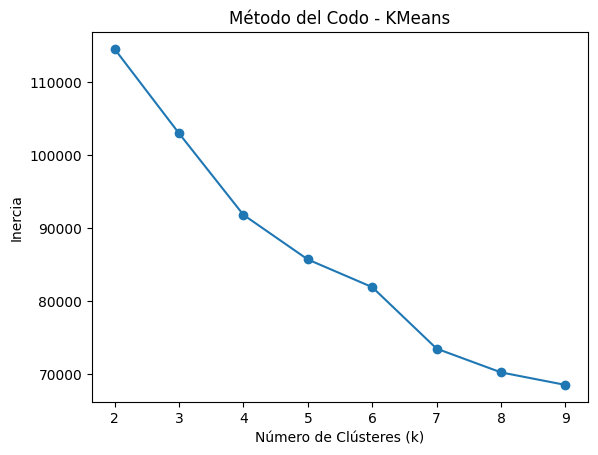

In [51]:
from sklearn.cluster import KMeans

# --- Determinamos el número óptimo de clústeres (método del codo) ---
inertia = []
K = range(2, 10)
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Método del Codo - KMeans")
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inercia")
plt.show()

K-Means con 3 Clusters

In [52]:
# --- Aplicamos K-Means con el k elegido (por ejemplo, 3) ---
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters

Visualizacion de datos

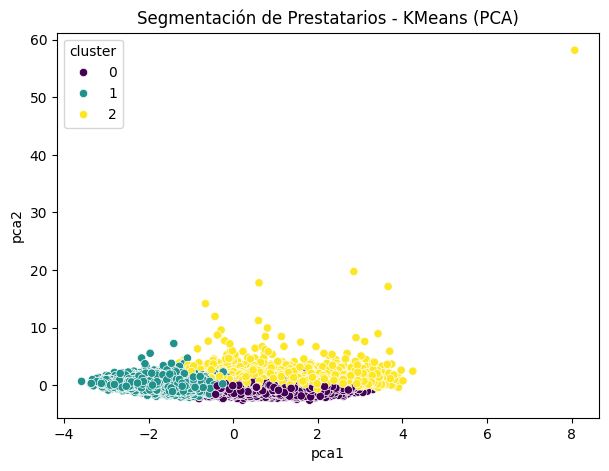

In [53]:
import seaborn as sns

# --- Visualización PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.title("Segmentación de Prestatarios - KMeans (PCA)")
plt.show()

Agregar el centroide

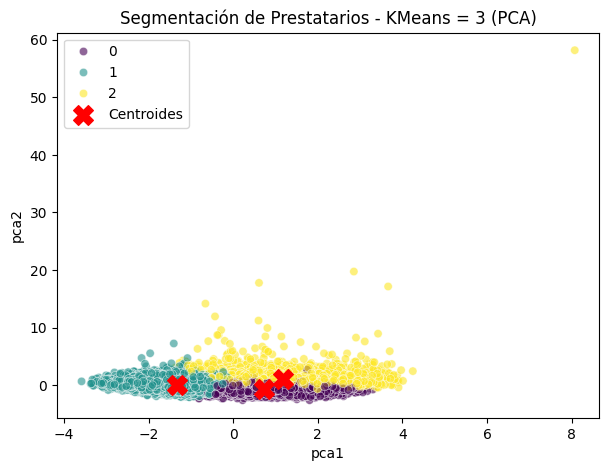

In [54]:
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis", alpha=0.6)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 3 (PCA)")
plt.legend()
plt.show()

Análisis descriptivo de cada clúster

In [55]:
# --- Análisis descriptivo de cada clúster ---
resumen_clusters = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", resumen_clusters)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8377.83     13.65    58303.06  15.22       68.24        1.95   
1            8389.60      9.10    64361.73  10.61       27.86        3.60   
2           22015.47     14.94   110827.67  13.38       54.69        2.71   

         purpose_code  
cluster                
0                3.45  
1                4.01  
2                3.30  


Evaluacion del Clustering

In [56]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette score con k = 3:", sil_score)
print("Inercia con k = 3:", kmeans.inertia_)

Silhouette score con k = 3: 0.17500296238951465
Inercia con k = 3: 102987.29562367518


Experimentar con Clusters = 2

In [57]:
# --- Aplicamos K-Means con 2 ---
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters

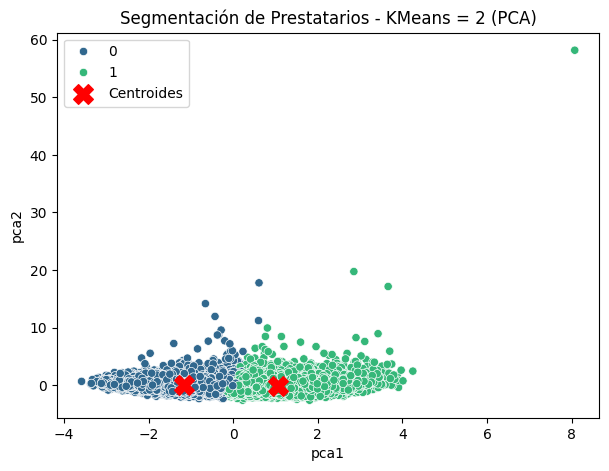

In [58]:
# --- Visualización PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 2 (PCA)")
plt.legend()
plt.show()

Análisis descriptivo de cada clúster

In [59]:
# --- Análisis descriptivo de cada clúster ---
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)



Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8946.18      9.45    67209.32  10.91       30.05        3.52   
1           12977.50     14.45    74555.88  14.89       66.80        2.08   

         purpose_code  
cluster                
0                3.99  
1                3.34  


Experimentar con Clusters = 4

In [60]:
# --- K-Means = 4 Clusters ---
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters

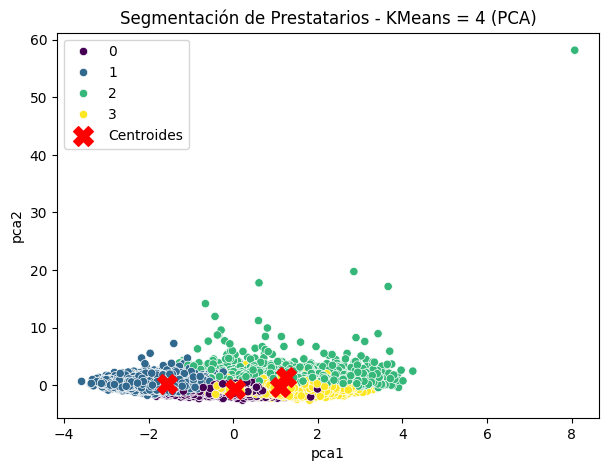

In [61]:

# --- Visualización PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 4 (PCA)")
plt.legend()
plt.show()

Analisis descriptivo de cada cluster

In [62]:
# --- Análisis descriptivo de cada clúster ---
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8858.55     11.82    59016.52  16.58       62.51        3.79   
1            8509.19      8.85    67177.66   8.59       23.22        3.66   
2           24047.28     15.04   123366.18  12.88       53.95        2.82   
3            9682.24     14.66    61839.78  13.79       61.44        0.30   

         purpose_code  
cluster                
0                3.32  
1                4.26  
2                3.29  
3                3.53  


In [63]:
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette score con k = 4:", sil_score)
print("Inercia con k = 4:", kmeans.inertia_)

Silhouette score con k = 4: 0.17911692512659802
Inercia con k = 4: 91831.10195333381


Optimización

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
resultados = []
K = range(2, 13) # Ajustar el rango dependiendo del rango K a probar
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X_scaled)
  inertia = kmeans.inertia_
  silhouette = silhouette_score(X_scaled, labels)
  calinski = calinski_harabasz_score(X_scaled, labels)
  davies = davies_bouldin_score(X_scaled, labels)
  resultados.append({
      "k": k,
      "inercia": inertia,
      "silhouette": silhouette,
      "calinski_harabasz": calinski,
      "davies_bouldin": davies
    })
df_resultados = pd.DataFrame(resultados)
df_resultados


,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,114535.763758,0.186848,4286.550518,1.930770
1,3,102987.295624,0.175003,3498.467049,1.923880
2,4,91831.101953,0.179117,3420.731967,1.694474
3,5,85720.530646,0.176836,3102.662101,1.651902
4,6,81933.878837,0.176854,2780.491228,1.667562
5,7,73514.064039,0.191413,2961.858557,1.519008
6,8,70266.716741,0.171336,2787.187139,1.560309
7,9,68553.278146,0.156100,2561.739979,1.659082
8,10,66744.371459,0.149993,2398.546941,1.595678
9,11,60496.988487,0.151791,2586.770654,1.488864


In [65]:
# Normalizamos algunas métricas para comparar
df_norm = df_resultados.copy()
# Queremos silhouette ALTO, calinski ALTO, davies BAJO, inertia BAJA
df_norm["rank"] = (
df_norm["silhouette"].rank(ascending=False) +
df_norm["calinski_harabasz"].rank(ascending=False) +
df_norm["davies_bouldin"].rank(ascending=True) +
df_norm["inercia"].rank(ascending=True)
)
k_optimo = df_norm.sort_values("rank").iloc[0]["k"]
print("K óptimo según combinación de métricas:", k_optimo)

K óptimo según combinación de métricas: 7.0


In [66]:
# --- K-Means = 7 Clusters ---
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters


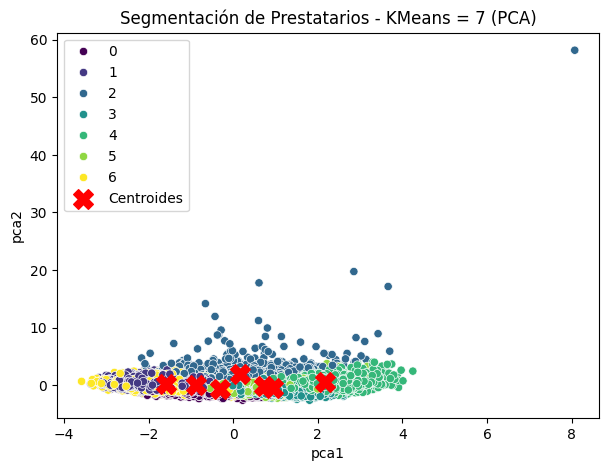

In [67]:
# --- Visualización PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 7 (PCA)")
plt.legend()
plt.show()

In [68]:
# --- Análisis descriptivo de cada clúster ---
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)



Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8791.15      9.82    58051.51  17.98       52.82        3.37   
1            7754.19      8.72    64752.42   7.24       24.40        3.69   
2           22672.94     11.99   143461.92   9.67       33.70        3.00   
3            7956.20     14.25    58675.46  13.03       59.85        0.22   
4           20890.06     16.74    88095.93  16.11       69.94        0.96   
5           12074.43     16.01    67510.68  14.33       71.52        4.99   
6            8362.79     11.55    63817.37  11.47       40.72        2.81   

         purpose_code  
cluster                
0                3.11  
1                3.27  
2                3.36  
3                3.06  
4                3.09  
5                3.08  
6               10.19  


In [69]:
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette score con k = 7:", sil_score)
print("Inercia con k = 7:", kmeans.inertia_)


Silhouette score con k = 7: 0.19141342285004462
Inercia con k = 7: 73514.06403876984


In [70]:
# --- Aplicamos K-Means con 2 ---
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign clusters to the 'data' DataFrame first, which has the correct (subset) index
data["cluster"] = clusters

# Create a new 'cluster' column in prestamos, aligning by index from 'data'.
# Rows in prestamos that were dropped when creating 'data' will initially get NaN.
prestamos['cluster'] = data['cluster'].reindex(prestamos.index)

# Fill NaN values (for rows not included in clustering) with -1 and convert to integer type.
prestamos['cluster'] = prestamos['cluster'].fillna(-1).astype(int)

prestamos['cluster'].value_counts() # 4. Ver cuántos registros hay en cada cluster
prestamos.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,grade_code,purpose_code,cluster
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,0.0,0.0,0.0,N,Cash,N,NaN,0,0,1
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,0.0,0.0,0.0,N,Cash,N,NaN,0,1,1
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,0.0,0.0,0.0,N,Cash,N,NaN,1,2,1
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,0.0,0.0,0.0,N,Cash,N,NaN,2,0,1
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,0.0,0.0,0.0,N,Cash,N,NaN,3,1,0
